In [61]:
%load_ext autoreload
%autoreload 2

# load general packages
import numpy as np
import copy
import time
import matplotlib.pyplot as plt
from matplotlib import cm

# load modules related to this exercise
from model_zurcher import zurcher
from solve_NFXP import solve_NFXP
import estimate_NFXP as estimate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Exercise 2

#### 1. Ensure that you understand the code zucher.sim_data

#### 2. Illustrate the likelihood function for different values of RC and c

In [62]:
# 1. set up
model = zurcher()
solver = solve_NFXP()

# 2. update starting values and solve model
N = 1000
T = 500
Vbar0 = np.zeros((model.n))
Vbar, pk = solver.poly(model.bellman, Vbar0, beta = model.beta, output=2)

# 3. simulate data
data = zurcher.sim_data(model, N, T, pk) 
samplesize = data.shape[0]

In [63]:
# 1. find the likelihood value for different combinations 
Vbar = np.zeros((model.n))
par_RC = copy.copy(model.RC)
par_c = copy.copy(model.c)

# 2. construct RC and c grids
NRC = 30
Nc = 20
RC = np.linspace(8, 15, NRC)
c = np.linspace(1, 4, Nc)

# 3. allocate
log_lik = np.zeros((NRC, Nc)) + np.nan

# 4. find p-guess (need to implement here since we only call likelihood function and only on RC and c)
tabulate = data.dx1.value_counts()
p = [tabulate[i]/sum(tabulate) for i in range(tabulate.size-1)]
model.p = p

# 5. loop over RC and c grid, compute log-likelihood and store
for i in range(NRC):
    if i%5==0: print(i)
    for j in range(Nc):
        pnames = ['RC', 'c']
        theta = np.array([RC[i], c[j]])
        mean_ll = -estimate.ll(theta, model, solver, data, pnames, no_guess = True) # remember model computes negative ll for min
        log_lik[i,j] = mean_ll*samplesize

# 6. re-inset the true parameters 
model.RC = copy.copy(par_RC)
model.c = copy.copy(par_c)

0
5
10
15
20
25


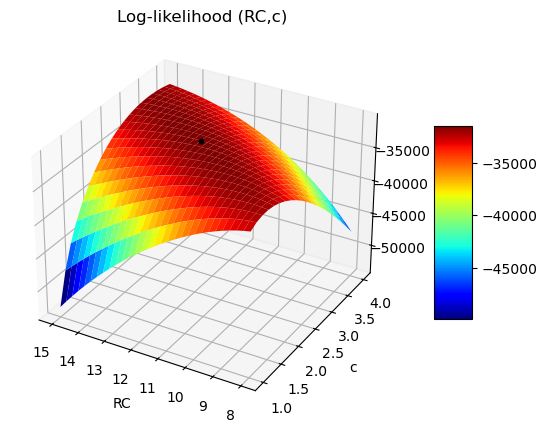

In [64]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1,projection='3d', computed_zorder=False)

# 1. plot surface
X, Y = np.meshgrid(RC, c, indexing='ij')
surf = ax.plot_surface(X, Y, log_lik, cmap=cm.jet)

# 2. plot max value
x, y = np.unravel_index(np.argmax(log_lik), log_lik.shape)
max = ax.scatter(RC[x], c[y], log_lik[x,y], color=['black'], marker='o', s=10)

# 3. customize the axes and add colorbar
ax.set_xlabel(f'RC')
ax.set_ylabel(f'c')
ax.set_title(f'Log-likelihood (RC,c)')
ax.invert_xaxis()
fig.colorbar(surf, shrink=0.5, aspect=5);

#### 3. Estimate the model, do you get the correct estimates?

In [65]:
def print_func(est_output, time_, par_RC, par_c):
    nfxp_model, optim_res, pnames, theta_hat, Avar, converged = est_output
    print(f'Structual estimation using simulated data')
    print(f'Beta        = {model.beta:.4f}')
    print(f'n           = {model.n}')
    print(f'Sample size = {samplesize}')
    print(f'True RC     = {par_RC}')
    print(f'True RC     = {par_c}\n \n')
    print(f'Parameters     Estimates    s.e. ') 
    print(f'{pnames[0]}             {theta_hat[0]:.4f}    {np.sqrt(Avar[0,0]):.4f} ')
    print(f'{pnames[1]}              {theta_hat[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')
    print(f'{pnames[2]}(1)           {theta_hat[2]:.4f}     {np.sqrt(Avar[2,2]):.4f}  ')
    print(f'{pnames[2]}(2)           {theta_hat[3]:.4f}     {np.sqrt(Avar[3,3]):.4f}  ')
    print(f'{pnames[2]}(3)           {theta_hat[4]:.4f}     {np.sqrt(Avar[4,4]):.4f}  ')
    print(f'{pnames[2]}(4)           {theta_hat[5]:.4f}     {np.sqrt(Avar[5,5]):.4f}  \n')
    print(f'Log-likelihood {-optim_res.fun*samplesize:.2f}') 
    print(f'runtime (seconds) {time_:.4f}')
    print(f'The model converged: {converged}')

Hint: use code from $\texttt{01\_NFXP.ipynb}$

In [66]:
### SOLUTION ###
t0 = time.time()
theta0 = [0,0]
output_aux1 = estimate.estimate(model, solver, data, theta0 = theta0, twostep=True)
nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux1
time_ = time.time()-t0
### SOLUTION ###

In [67]:
print_func(output_aux1, time_, par_RC, par_c)

Structual estimation using simulated data
Beta        = 0.9999
n           = 175
Sample size = 500000
True RC     = 11.7257
True RC     = 2.45569
 

Parameters     Estimates    s.e. 
RC             11.7158    0.1273 
c              2.4974     0.0395 
 
p(1)           0.0937     0.0004  
p(2)           0.4476     0.0008  
p(3)           0.4457     0.0008  
p(4)           0.0128     0.0002  

Log-likelihood -531104.06
runtime (seconds) 3.1812
The model converged: True


Try changing the starting values, does the model converges?

In [68]:
### SOLUTION ###
t0 = time.time()
theta0 = [10,10]
output_aux2 = estimate.estimate(model, solver, data, theta0 = theta0, twostep=True)
nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux2
time_ = time.time()-t0
### SOLUTION ###

In [69]:
print_func(output_aux2, time_, par_RC, par_c)

Structual estimation using simulated data
Beta        = 0.9999
n           = 175
Sample size = 500000
True RC     = 11.7257
True RC     = 2.45569
 

Parameters     Estimates    s.e. 
RC             11.7158    0.1273 
c              2.4974     0.0395 
 
p(1)           0.0937     0.0004  
p(2)           0.4476     0.0008  
p(3)           0.4457     0.0008  
p(4)           0.0128     0.0002  

Log-likelihood -531104.06
runtime (seconds) 2.8212
The model converged: True


#### 4. What happen if you change the maximum number of Newton-Kantorovich iterations and switches between NK and SA to 1? 
Do we get convergence? Do the estimates seem right? 


In [70]:
### SOLUTION ###
t0 = time.time()
theta0 = [0,0]
solver.pi_max = 5
solver.max_fxpiter = 1
output_aux3 = estimate.estimate(model, solver, data, theta0 = theta0, twostep=True)
nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux3
time_ = time.time()-t0
### SOLUTION ###

In [71]:
print_func(output_aux3, time_, par_RC, par_c)

Structual estimation using simulated data
Beta        = 0.9999
n           = 175
Sample size = 500000
True RC     = 11.7257
True RC     = 2.45569
 

Parameters     Estimates    s.e. 
RC             11.7158    0.1273 
c              2.4974     0.0395 
 
p(1)           0.0937     0.0004  
p(2)           0.4476     0.0008  
p(3)           0.4457     0.0008  
p(4)           0.0128     0.0002  

Log-likelihood -531104.06
runtime (seconds) 1.5156
The model converged: True
